## Step 1: Import Libraries and Set Random Seeds

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
print("Libraries imported and random seeds set.")

Libraries imported and random seeds set.


## Step 2: Dataset Loading and Preprocessing

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Original training data shape: {x_train.shape}, {y_train.shape}")
print(f"Original testing data shape: {x_test.shape}, {y_test.shape}")

# Normalize pixel values to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape((-1, 28 * 28))
x_test = x_test.reshape((-1, 28 * 28))

# Convert class labels into one-hot encoded vectors
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

print(f"Processed training data shape: {x_train.shape}, {y_train.shape}")
print(f"Processed testing data shape: {x_test.shape}, {y_test.shape}")
print("MNIST dataset loaded and preprocessed.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training data shape: (60000, 28, 28), (60000,)
Original testing data shape: (10000, 28, 28), (10000,)
Processed training data shape: (60000, 784), (60000, 10)
Processed testing data shape: (10000, 784), (10000, 10)
MNIST dataset loaded and preprocessed.


## Step 3: Model Architecture Design & Step 4: Weight Initialization Experiments

In [3]:
def build_mlp_model(initializer):
    """Builds a Deep Perceptron (MLP) model with specified initializer."""
    model = keras.Sequential([
        keras.Input(shape=(784,)),
        layers.Dense(128, activation='relu', kernel_initializer=initializer),
        layers.Dense(64, activation='relu', kernel_initializer=initializer),
        layers.Dense(10, activation='softmax')
    ])
    return model

def train_model_with_initializer(
    initializer_name,
    initializer,
    x_train,
    y_train,
    x_test,
    y_test,
    epochs=10,
    batch_size=128
):
    """Builds, compiles, and trains an MLP model with the given initializer."""
    print(f"\n--- Training with {initializer_name} Initialization ---")
    model = build_mlp_model(initializer)

    model.compile(
        optimizer=keras.optimizers.Adam(), # Fixed optimizer for initialization comparison
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
        verbose=0 # Set verbose to 0 to suppress output during training
    )
    print(f"Training with {initializer_name} complete.")
    return history

In [4]:
# Define initializers
initializers = {
    'RandomNormal': keras.initializers.RandomNormal(),
    'GlorotUniform': keras.initializers.GlorotUniform(), # Xavier initializer
    'HeNormal': keras.initializers.HeNormal()
}

# Dictionary to store training histories
histories_initializers = {}

# Train model with each initializer
for name, initializer in initializers.items():
    history = train_model_with_initializer(
        initializer_name=name,
        initializer=initializer,
        x_train=x_train, y_train=y_train,
        x_test=x_test, y_test=y_test,
        epochs=10 # Using a fixed number of epochs for comparison
    )
    histories_initializers[name] = history

print("All weight initialization experiments complete.")


--- Training with RandomNormal Initialization ---
Training with RandomNormal complete.

--- Training with GlorotUniform Initialization ---
Training with GlorotUniform complete.

--- Training with HeNormal Initialization ---
Training with HeNormal complete.
All weight initialization experiments complete.


## Step 6: Performance Visualization - Weight Initialization

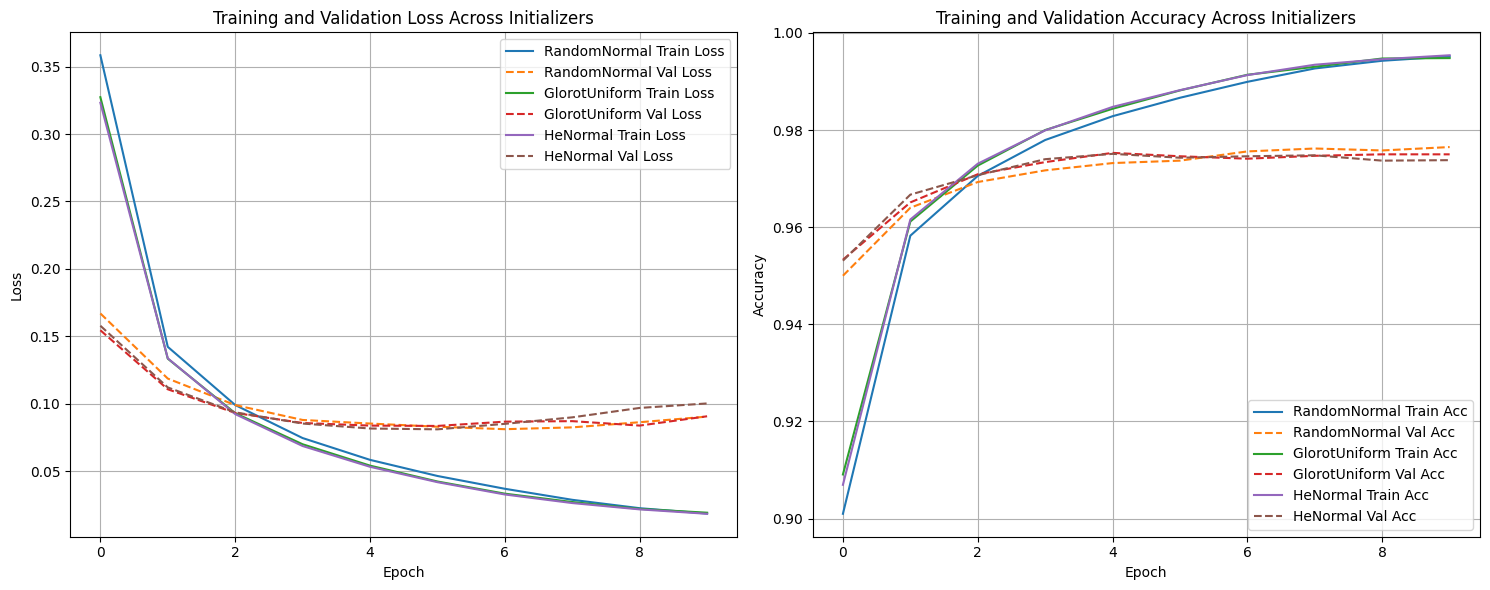

In [5]:
plt.figure(figsize=(15, 6))

# Plot Training Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
for name, history in histories_initializers.items():
    plt.plot(history.history['loss'], label=f'{name} Train Loss')
    plt.plot(history.history['val_loss'], linestyle='--', label=f'{name} Val Loss')
plt.title('Training and Validation Loss Across Initializers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
for name, history in histories_initializers.items():
    plt.plot(history.history['accuracy'], label=f'{name} Train Acc')
    plt.plot(history.history['val_accuracy'], linestyle='--', label=f'{name} Val Acc')
plt.title('Training and Validation Accuracy Across Initializers')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Step 5: Optimizer Comparison

In [6]:
def train_model_with_optimizer(
    optimizer_name,
    optimizer,
    initializer, # Use the best performing initializer from previous step
    x_train,
    y_train,
    x_test,
    y_test,
    epochs=10,
    batch_size=128
):
    """Builds, compiles, and trains an MLP model with the given optimizer and a fixed initializer."""
    print(f"\n--- Training with {optimizer_name} Optimizer ---")
    model = build_mlp_model(initializer) # Reusing the model building function

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
        verbose=0 # Set verbose to 0 to suppress output during training
    )
    print(f"Training with {optimizer_name} complete.")
    return history

# Choosing GlorotUniform as the best performing initializer for this comparison
best_initializer = keras.initializers.GlorotUniform()

# Define optimizers
optimizers = {
    'SGD': keras.optimizers.SGD(),
    'Adam': keras.optimizers.Adam()
}

# Dictionary to store training histories for optimizers
histories_optimizers = {}

# Train model with each optimizer using the best initializer
for name, optimizer in optimizers.items():
    history = train_model_with_optimizer(
        optimizer_name=name,
        optimizer=optimizer,
        initializer=best_initializer,
        x_train=x_train, y_train=y_train,
        x_test=x_test, y_test=y_test,
        epochs=10 # Using a fixed number of epochs for comparison
    )
    histories_optimizers[name] = history

print("All optimizer comparison experiments complete.")


--- Training with SGD Optimizer ---
Training with SGD complete.

--- Training with Adam Optimizer ---
Training with Adam complete.
All optimizer comparison experiments complete.


## Step 6: Performance Visualization - Optimizer Comparison

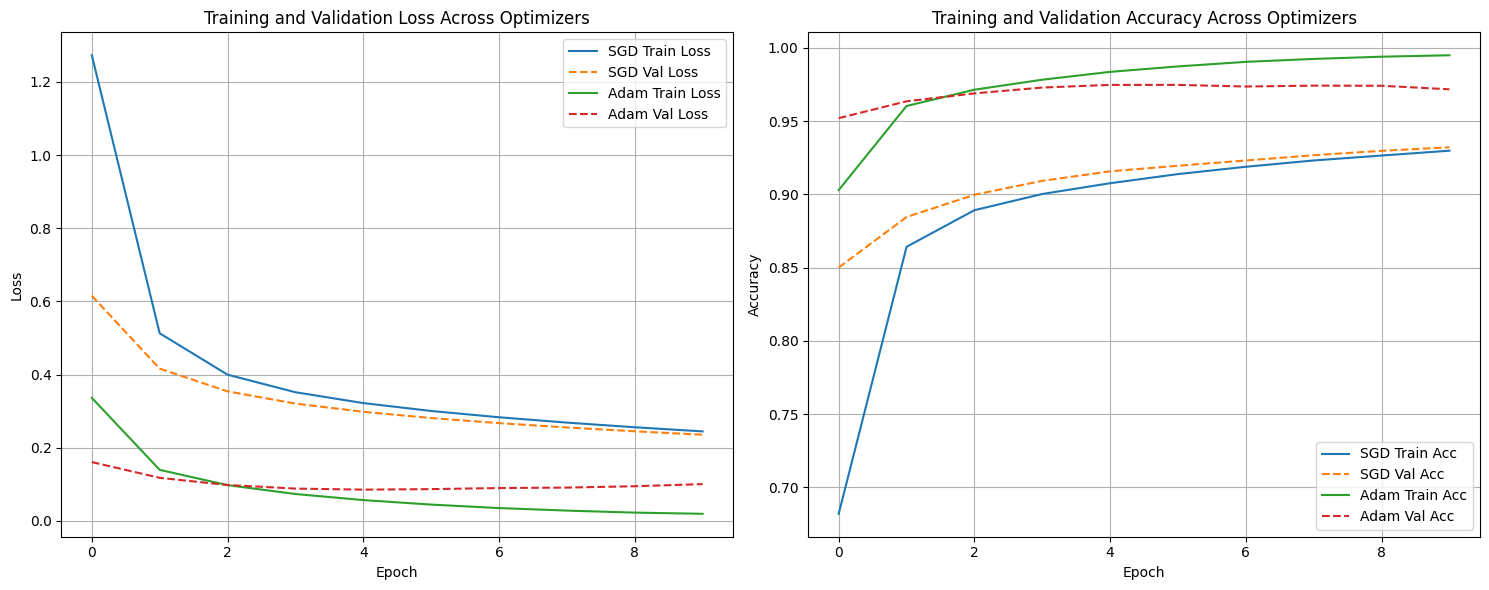

In [7]:
plt.figure(figsize=(15, 6))

# Plot Training Loss for Optimizers
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
for name, history in histories_optimizers.items():
    plt.plot(history.history['loss'], label=f'{name} Train Loss')
    plt.plot(history.history['val_loss'], linestyle='--', label=f'{name} Val Loss')
plt.title('Training and Validation Loss Across Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training Accuracy for Optimizers
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
for name, history in histories_optimizers.items():
    plt.plot(history.history['accuracy'], label=f'{name} Train Acc')
    plt.plot(history.history['val_accuracy'], linestyle='--', label=f'{name} Val Acc')
plt.title('Training and Validation Accuracy Across Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()